 Scenario-Based Question

 A university wants to build a predictive model to estimate
  student grades based on four factors:
 - Study hours per week
 - Attendance percentage
 - Previous exam score
 - Average sleep hours

 They collect data from 200 students and decide to use Ridge
  Regression for prediction. To evaluate the model, they apply different cross-validation strategies:
 - Basic K-Fold CV (5 folds, shuffled) to check the stability of the model’s R² scores.
 - Multi-metric evaluation using both R² and Mean Squared Error (MSE), comparing training and validation
 scores.
 - Stratified K-Fold CV (for a separate classification task predicting pass/fail using Logistic                        Regression).

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score,KFold
from sklearn.datasets import make_regression
import numpy as np

x,y=make_regression(n_samples=1000,n_features=5,noise=15,random_state=42)

model=LinearRegression()
kf=KFold(n_splits=5,shuffle=True,random_state=42)
scores=cross_val_score(model,x,y,cv=kf,scoring='r2')
print("R2 scores for each fold:",scores.round(3))
print("Mean R2:" ,scores.mean().round(3))
print("Standard Deviation:",scores.std().round(3))

if scores.std()<0.05:
  print("Model is stable across folds")
else:
  print("Model is not stable across folds")

R2 scores for each fold: [0.937 0.945 0.945 0.947 0.947]
Mean R2: 0.944
Standard Deviation: 0.004
Model is stable across folds


Scenario: Predicting Patient Recovery Time

A hospital research team wants to build a model to predict patient recovery time (in days) after
surgery based on several factors such as:
- Age of the patient
 - Number of hours of post-surgery physiotherapy per week
 - Pre-existing health conditions (numeric severity score)
 - Length of hospital stay (days)
 - Average sleep hours during recovery

 They collect data from 1,000 patients and decide to use Linear Regression.
 To evaluate the model, they apply 5-Fold Cross-Validation with R² as the performance metric.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
n=1000
data=pd.DataFrame({
    "Age":np.random.randint(20, 80, n),
    "Physiotherapy_Hours":np.random.randint(1, 10, n),
    "Health_Severity":np.random.randint(1, 10, n),
    "Hospital_Stay":np.random.randint(1, 15, n),
    "Sleep_Hours":np.random.randint(4, 10, n)
})

data["Recovery_Time"]=(
    0.3 * data["Age"]
    - 1.2 * data["Physiotherapy_Hours"]
    + 2.5 * data["Health_Severity"]
    + 1.5 * data["Hospital_Stay"]
    - 0.8 * data["Sleep_Hours"]
    + np.random.normal(0, 5, n)
)

X=data[["Age", "Physiotherapy_Hours", "Health_Severity",
          "Hospital_Stay", "Sleep_Hours"]]

y=data["Recovery_Time"]

scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
model=LinearRegression()

kf=KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores=cross_val_score(model, X_scaled, y, cv=kf, scoring='r2')
print("R² Scores for each fold:", r2_scores.round(2))
print("Average R² Score:", np.mean(r2_scores).round(3))

R² Scores for each fold: [0.86 0.82 0.77 0.85 0.8 ]
Average R² Score: 0.819


Scenario: Predicting Student Exam Performance
A university research team wants to build a model to predict student exam scores (out of 100) based on several factors such as:
- Number of study hours per week
- Attendance percentage in lectures
- Prior GPA (Grade Point Average)
- Participation in group projects (numeric engagement score)
- Average sleep hours during exam preparation

They collect data from 800 students across different departments and decide to use Linear Regression.

To evaluate the model, they apply 5-Fold Cross-Validation with R² as the performance metric.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score,KFold
from sklearn.datasets import make_regression
import numpy as np

x,y=make_regression(n_samples=800,n_features=5,noise=20,random_state=52)

model=LinearRegression()
kf=KFold(n_splits=5,shuffle=True,random_state=52)
scores=cross_val_score(model,x,y,cv=kf,scoring='r2')
print("R2 scores for each fold:",scores.round(3))
print("Mean R2:" ,scores.mean().round(3))
print("Standard Deviation:",scores.std().round(3))

if scores.std()<0.05:
  print("Model is stable across folds")
else:
  print("Model is not stable across folds")

R2 scores for each fold: [0.974 0.981 0.982 0.977 0.979]
Mean R2: 0.979
Standard Deviation: 0.003
Model is stable across folds


 Scenario: Predicting Student Exam Scores

 A school wants to build a model to predict student exam scores based on study hours. They collect data
 from 30 students, but the scores are noisy because of other factors (like sleep, stress, or health).

 They try two different models:
- Linear Model (straight line) → very simple, assumes scores increase perfectly with study hours.
 - Polynomial Model (degree 10 curve) → very complex, tries to follow every bump in the data.

Questions
 - Part A: If the linear model consistently predicts too low or too high compared to actual scores,
what does this show about bias?
 - Part B: If the polynomial model fits the training data almost perfectly but gives very different predictions when tested on new students, what does this show about variance?
 - Part C: Which model is likely to generalize better to new students, and why?
 - Part D (Applied): How would you explain the difference between “high bias” and “high variance” to
a teacher who doesn’t know machine learning?

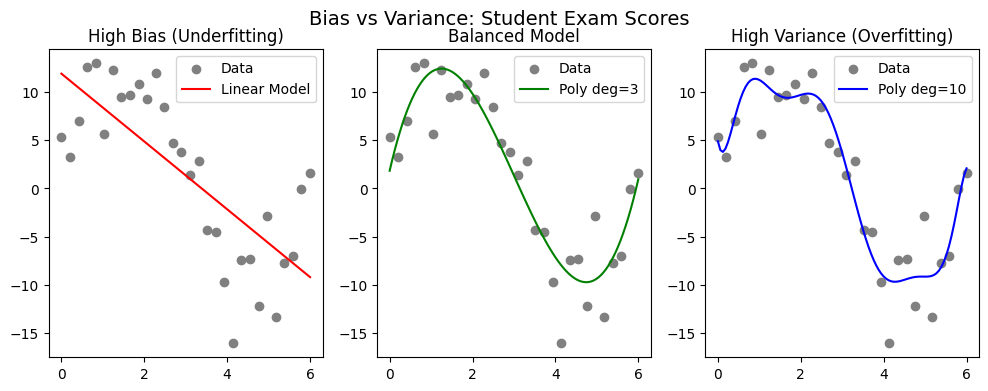

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.random.seed(0)
X=np.linspace(0,6,30).reshape(-1,1)
y=(10*np.sin(X).ravel()+np.random.normal(scale=3,size=30))

linear_model=make_pipeline(PolynomialFeatures(1),LinearRegression())
poly_model=make_pipeline(PolynomialFeatures(10),LinearRegression())
balanced_model=make_pipeline(PolynomialFeatures(3),LinearRegression())
linear_model.fit(X,y)
poly_model.fit(X,y)
balanced_model.fit(X,y)

X_test = np.linspace(0, 6, 100).reshape(-1, 1)
y_linear   = linear_model.predict(X_test)
y_poly     = poly_model.predict(X_test)
y_balanced = balanced_model.predict(X_test)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_linear, color="red", label="Linear Model")
plt.title("High Bias (Underfitting)")
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_balanced, color="green", label="Poly deg=3")
plt.title("Balanced Model")
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_poly, color="blue", label="Poly deg=10")
plt.title("High Variance (Overfitting)")
plt.legend()

plt.suptitle("Bias vs Variance: Student Exam Scores", fontsize=14)
plt.show()


 Scenario: Predicting Athlete Performance

A sports academy wants to build a model to predict athlete sprint times (in seconds) based on training
  hours. They collect data from 30 athletes, but the sprint times are noisy because of other factors (like diet, fatigue, or weather).

 They try two different models:
 - Linear Model (straight line) → very simple, assumes sprint times improve perfectly with more
  training hours.
 - Polynomial Model (degree 10 curve) → very complex, tries to follow every bump in the data.

 Questions
 - Part A: If the linear model consistently predicts sprint times that are too fast or too slow compared
  to actual results, what does this show about bias?
 - Part B: If the polynomial model fits the training data almost perfectly but gives very different
 predictions when tested on new athletes, what does this show about variance?
 - Part C: Which model is likely to generalize better to new athletes, and why?
- Part D (Applied): How would you explain the difference between “high bias” and “high variance”
 to a coach who doesn’t know machine learning?

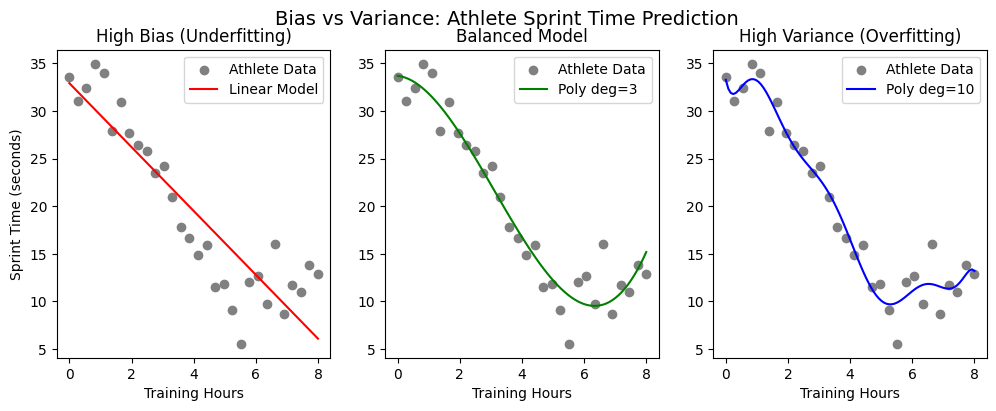

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.random.seed(0)

X = np.linspace(0, 8, 30).reshape(-1, 1)
y = (30 - 3*X.ravel() + 4*np.sin(X).ravel() + np.random.normal(scale=2, size=30))

linear_model = make_pipeline(PolynomialFeatures(1), LinearRegression())   # Simple line
poly_model = make_pipeline(PolynomialFeatures(10), LinearRegression())    # Very complex
balanced_model = make_pipeline(PolynomialFeatures(3), LinearRegression()) # Balanced

linear_model.fit(X, y)
poly_model.fit(X, y)
balanced_model.fit(X, y)

X_test = np.linspace(0, 8, 100).reshape(-1, 1)

y_linear = linear_model.predict(X_test)
y_poly = poly_model.predict(X_test)
y_balanced = balanced_model.predict(X_test)

plt.figure(figsize=(12, 4))


plt.subplot(1, 3, 1)
plt.scatter(X, y, color="gray", label="Athlete Data")
plt.plot(X_test, y_linear, color="red", label="Linear Model")
plt.title("High Bias (Underfitting)")
plt.xlabel("Training Hours")
plt.ylabel("Sprint Time (seconds)")
plt.legend()


plt.subplot(1, 3, 2)
plt.scatter(X, y, color="gray", label="Athlete Data")
plt.plot(X_test, y_balanced, color="green", label="Poly deg=3")
plt.title("Balanced Model")
plt.xlabel("Training Hours")
plt.legend()


plt.subplot(1, 3, 3)
plt.scatter(X, y, color="gray", label="Athlete Data")
plt.plot(X_test, y_poly, color="blue", label="Poly deg=10")
plt.title("High Variance (Overfitting)")
plt.xlabel("Training Hours")
plt.legend()

plt.suptitle("Bias vs Variance: Athlete Sprint Time Prediction", fontsize=14)
plt.show()

 Scenario: Package Delivery System

 A logistics company wants to build a machine learning model to optimize package delivery.

 They collect data about each package, including:
 - Size: Small, Medium, Large
 - Priority: Low, Medium, High

 Since machine learning models work with numbers (not text labels), the company decides to use Label
  Encoding to convert these categories into numeric values.
 They apply Scikit-learn’s LabelEncoder to both features:
 - Size → converted into numeric codes (e.g., Small = 2, Medium = 1, Large = 0)
- Priority → converted into numeric codes (e.g., Low = 1, Medium = 2, High = 0)

 They also check the mapping and decode the numbers back to the original labels to ensure correctness.

 Questions for Learners

 Part A: Why does the company need to convert categorical values like Small, Medium, Large into numbers
 before training a model?

 Part B: If the encoded values are 0, 1, 2, does the order (e.g., Large = 0, Medium = 1, Small = 2)
matter for all models? Why or why not?

 Part C: How can the company decode the numeric values back into the original labels after prediction?

 Part D (Applied): Suppose the company adds a new category “Extra Large.” How would LabelEncoder handle
 this, and what challenge might arise if the model was already trained?

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

data = pd.DataFrame({
    'Size': ['Small', 'Medium', 'Large', 'Medium', 'Small'],
    'Priority': ['Low', 'High', 'Medium', 'Low', 'High']
})

le_encoder=LabelEncoder()
data['Size_Encoded']=le_encoder.fit_transform(data['Size'])
le_priority=LabelEncoder()
data['Priority_Encoded']=le_priority.fit_transform(data['Priority'])

print("Size mapping:",dict(zip(le_encoder.classes_,le_encoder.transform(le_encoder.classes_))))
print("Priority mapping:",dict(zip(le_priority.classes_,le_priority.transform(le_priority.classes_))))

decoded_size=le_encoder.inverse_transform([0, 1,2])
print("Decoded Size:",decoded_size)

print("Encoded DataFrame:")
print(data)



Size mapping: {'Large': np.int64(0), 'Medium': np.int64(1), 'Small': np.int64(2)}
Priority mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Decoded Size: ['Large' 'Medium' 'Small']
Encoded DataFrame:
     Size Priority  Size_Encoded  Priority_Encoded
0   Small      Low             2                 1
1  Medium     High             1                 0
2   Large   Medium             0                 2
3  Medium      Low             1                 1
4   Small     High             2                 0


One-Hot Encoding on the Blood Type column.

In [ ]:
import pandas as pd

data = pd.DataFrame({
    'Patient_ID': ['P001', 'P002', 'P003'],
    'Blood_Type': ['O+', 'A+', 'B+'],
    'Age': [45, 52, 38],
    'Risk': ['Low', 'High', 'Medium']
})

encoded_data = pd.get_dummies(data, columns=['Blood_Type'])

print(encoded_data)

  Patient_ID  Age    Risk  Blood_Type_A+  Blood_Type_B+  Blood_Type_O+
0       P001   45     Low          False          False           True
1       P002   52    High           True          False          False
2       P003   38  Medium          False           True          False


In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

data = pd.DataFrame({
    'Patient_ID': ['P001', 'P002', 'P003'],
    'Blood_Type': ['O+', 'A+', 'B+'],
    'Age': [45, 52, 38],
    'Risk': ['Low', 'High', 'Medium']
})

encoder = OneHotEncoder(sparse_output=False)

encoded_array = encoder.fit_transform(data[['Blood_Type']])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(['Blood_Type'])
)

final_data = pd.concat([data.drop('Blood_Type', axis=1), encoded_df], axis=1)

print(final_data)

  Patient_ID  Age    Risk  Blood_Type_A+  Blood_Type_B+  Blood_Type_O+
0       P001   45     Low            0.0            0.0            1.0
1       P002   52    High            1.0            0.0            0.0
2       P003   38  Medium            0.0            1.0            0.0


 Scenario: Employee Training & Satisfaction Survey

A company conducts a survey to understand how employee education level and job satisfaction affect performance.
 They collect data such as:
- Education: High School, Bachelor, Master, PhD
 - Satisfaction: Poor, Average, Good, Excellent
 Since these categories have a natural order (e.g., PhD is higher than Bachelor, Excellent is better
  than Good), the company decides to use Ordinal Encoding to convert them into numbers that respect
  this ranking.
 They define custom ordering:
- Education → High School (0), Bachelor (1), Master (2), PhD (3)
 - Satisfaction → Poor (0), Average (1), Good (2), Excellent (3)

They also compare this with a manual dictionary mapping to ensure consistency.

 Questions for Learners

 Part A: Why is it important to use Ordinal Encoding instead of simple Label Encoding for ordered
 categories like education level?

 Part B: If the company encoded “PhD = 0” and “High School = 3,” what problem might arise in
 interpreting the model?

 Part C: How does Ordinal Encoding differ from One-Hot Encoding in representing categorical data?

Part D (Applied): Suppose the company adds a new satisfaction level “Outstanding.” How should they
 update their encoding scheme to keep the order meaningful?

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
data=pd.DataFrame({
    'Education':['High School','Bachelor','Master','PhD'],
    'Satisfaction':['Poor','Average','Good','Excellent']
})
eduaction_order=[['High School','Bachelor','Master','PhD']]
satisfaction_order=[['Poor','Average','Good','Excellent']]

edu_encoder=OrdinalEncoder(categories=eduaction_order)
data['Education_Encoded']=edu_encoder.fit_transform(data[['Education']])

sat_encoder=OrdinalEncoder(categories=satisfaction_order)
data['Satisfaction_Encoded']=sat_encoder.fit_transform(data[['Satisfaction']])

education_map={
    'High School':0,
    'Bachelor':1,
    'Master':2,
    'PhD':3
}

satisfaction_map={
    'Poor':0,
    'Average':1,
    'Good':2,
    'Excellent':3
}

data['Edcatiom_Manual']=data['Education'].map(education_map)
data['Satisfaction_Manual']=data['Satisfaction'].map(satisfaction_map)

print(data)

     Education Satisfaction  ...  Edcatiom_Manual  Satisfaction_Manual
0  High School         Poor  ...                0                    0
1     Bachelor      Average  ...                1                    1
2       Master         Good  ...                2                    2
3          PhD    Excellent  ...                3                    3

[4 rows x 6 columns]


Scenario: Online Food Delivery App

 An online food delivery company wants to build a machine learning model to predict delivery time based
  on the type of cuisine ordered.

They collect data such as:
 - Cuisine Type: Italian, Chinese, Indian, Mexican
Since machine learning models can’t directly work with text labels, the company decides to use One-Hot
  Encoding.

 This method creates a new column for each cuisine type:
- Italian → [1, 0, 0, 0]
 - Chinese → [0, 1, 0, 0]
 - Indian → [0, 0, 1, 0]
 - Mexican → [0, 0, 0, 1]
 They set sparse=False so the encoder returns a regular NumPy array instead of a sparse matrix, making
  the results easier to read and print for analysis.

Questions for Learners

Part A: Why is One-Hot Encoding more appropriate than Label Encoding for categories like cuisine type?

 Part B: What does sparse=False do, and why might it be useful in this scenario?

 Part C: If the company adds a new cuisine type (e.g., “Thai”), how will One-Hot Encoding handle it?

 Part D (Applied): What potential problem could arise if the company has hundreds of cuisine types, and
  how might they solve it?

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

orders=pd.DataFrame({
    'Cuisine': ['Italian','Chinese','Indian','Mexican','Chinese','Italian']
})

encoder=OneHotEncoder(sparse_output=False)
encoded_data=encoder.fit_transform(orders[['Cuisine']])

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(['Cuisine'])
)

final_data = pd.concat([orders, encoded_df], axis=1)

print('Cuisine Categories',encoder.categories_)
print("Encoded Array:", encoded_array)
print('Final Data')
print(final_data)

Cuisine Categories [array(['Chinese', 'Indian', 'Italian', 'Mexican'], dtype=object)]
Encoded Array: [[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]
Final Data
   Cuisine  Cuisine_Chinese  Cuisine_Indian  Cuisine_Italian  Cuisine_Mexican
0  Italian              0.0             0.0              1.0              0.0
1  Chinese              1.0             0.0              0.0              0.0
2   Indian              0.0             1.0              0.0              0.0
3  Mexican              0.0             0.0              0.0              1.0
4  Chinese              1.0             0.0              0.0              0.0
5  Italian              0.0             0.0              1.0              0.0
